# Labwork 6

(540, 720, 3)


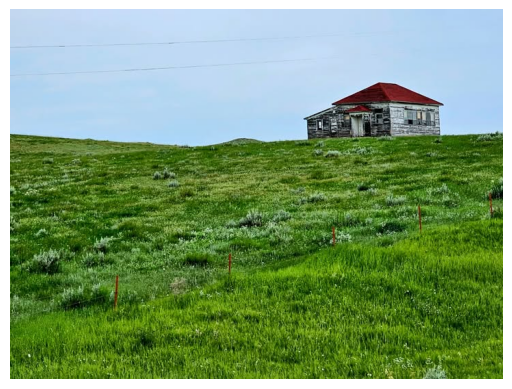

In [63]:
%matplotlib inline
import matplotlib.pyplot as plt

# Force high-resolution PNG outputs if needed
%config InlineBackend.figure_format = 'png' 
from time import time

from PIL import Image
import numpy as np
from numba import cuda

if not hasattr(np, 'row_stack'):
        np.row_stack = np.vstack

# img = image.imread("cat.jpg")
img = np.array(Image.open("../data/house.jpg").convert("RGB"))
pixelCount = img.shape[0] * img.shape[1]
img_flat = img.reshape(pixelCount, 3)

print (img.shape)
plt.imshow(img)
plt.axis("off")
plt.show()

In [64]:
def save_log(data):
    with open("log.csv", "a") as f:
        f.write(f"{data}\n")

In [65]:
# Grayscale Binarization
from numba import uint8

@cuda.jit
def binarize_gpu(src, dst, threshold) -> None:

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x # type: ignore
    g = uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)

    dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = 0 if g < threshold else 255

In [66]:
# Brightness
@cuda.jit
def brightness_gpu(src, dst, factor) -> None:

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x # type: ignore
    dst[tidx, 0] = src[tidx, 0] + factor
    dst[tidx, 1] = src[tidx, 1] + factor
    dst[tidx, 2] = src[tidx, 2] + factor


In [ ]:
# Blending
@cuda.jit
def blend_gpu(phi1, phi2, dst, coefficient) -> None:

    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x # type: ignore
    if tidx >= phi1.shape[0]: return
    for k in range(3):
        dst[tidx,k] = int(coefficient * phi1[tidx,k] + (1 - coefficient) * phi2[tidx,k])


In [68]:
def run(kernel, grid, block, *args):
    kernel[grid, block](*args)
    cuda.synchronize()
    t0 = time()
    kernel[grid, block](*args)
    cuda.synchronize()
    return time() - t0

GPU binarize: 0.2162 ms
GPU brightness: 0.1009 ms
GPU blend: 0.2897 ms


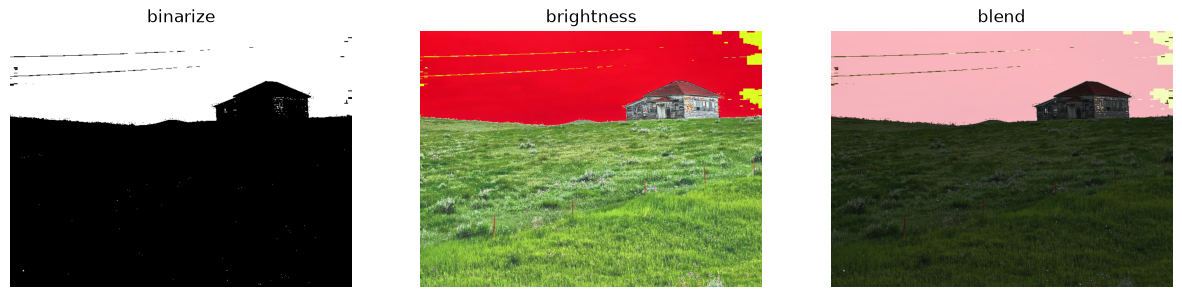

In [ ]:
def main():
    threshold, factor, coefficient = 207, 47, 0.7
    blockSize = 64
    gridSize = (pixelCount + blockSize - 1) // blockSize

    devInput  = cuda.to_device(img_flat)
    devBin    = cuda.device_array((pixelCount, 3), dtype=np.uint8)
    devBright = cuda.device_array((pixelCount, 3), dtype=np.uint8)
    devBlend  = cuda.device_array((pixelCount, 3), dtype=np.uint8)

    results = {}
    results["binarize"]   = run(binarize_gpu,   gridSize, blockSize, devInput, devBin, threshold)
    results["brightness"] = run(brightness_gpu, gridSize, blockSize, devInput, devBright, factor)
    results["blend"]      = run(blend_gpu,      gridSize, blockSize, devBin, devBright, devBlend, coefficient)

    for name, t in results.items():
        print(f"GPU {name}: {t*1000:.4f} ms")
        save_log(f"GPU,{name},{blockSize},{t*1000:.6f}")

    outs = [devBin, devBright, devBlend]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, d, title in zip(axes, outs, results):
        ax.imshow(d.copy_to_host().reshape(img.shape))
        ax.set_title(title); ax.axis("off")
    plt.show()
    

if __name__ == "__main__":
    main()